### Imports & data

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

RANDOM_STATE = 42

data = load_breast_cancer()
X, y = data.data, data.target

print("Feature matrix shape:", X.shape)
print("Target classes:", np.unique(y))


Feature matrix shape: (569, 30)
Target classes: [0 1]


### train/test split + scaling

PCA is distance/variance based, so features need to be on the same scale *before*
PCA is applied, otherwise high-magnitude features (like `mean area`) would
dominate the principal components just because of their raw scale, not because
they're actually more informative.

Scaler is fit on training data only, then applied to test data, to avoid leakage.
Same split reused across every condition in this notebook.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train_scaled.shape, "| Test size:", X_test_scaled.shape)


Train size: (455, 30) | Test size: (114, 30)


### Explained variance : how much does each component actually carry?

Before deciding how many components to keep, let's look at how much variance
each principal component explains, and how quickly that accumulates.


In [4]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

n_95 = np.argmax(cumulative >= 0.95) + 1
print(f"Number of components needed for 95% variance: {n_95}")
print(f"Total original features: {X.shape[1]}")


Number of components needed for 95% variance: 10
Total original features: 30


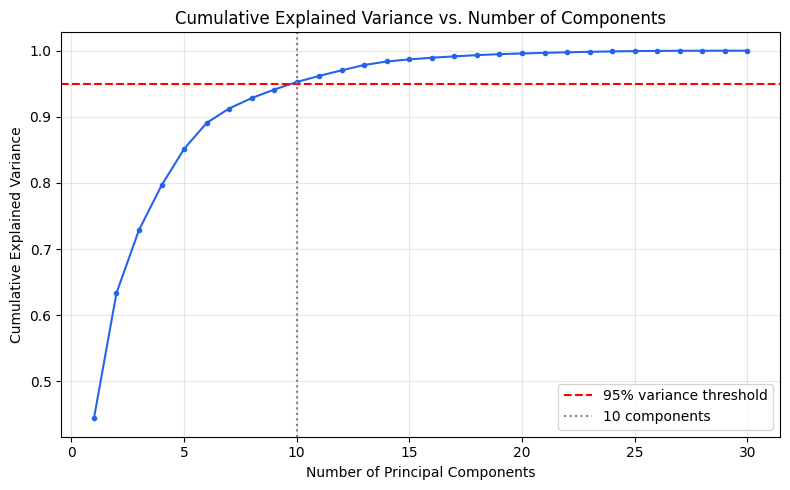

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(cumulative) + 1), cumulative, marker="o", markersize=3, color="#2563eb")
ax.axhline(0.95, color="red", linestyle="--", label="95% variance threshold")
ax.axvline(n_95, color="gray", linestyle=":", label=f"{n_95} components")
ax.set_xlabel("Number of Principal Components")
ax.set_ylabel("Cumulative Explained Variance")
ax.set_title("Cumulative Explained Variance vs. Number of Components")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Reading this plot:** if the curve rises steeply in the first few components and
then flattens out, most of the dataset's information is concentrated in a small
number of directions, which means heavy compression (like 2 components) may not lose
as much as you'd expect. If it rises slowly and stays close to a straight line,
each feature is contributing roughly equally, and cutting components down
aggressively will genuinely throw away information.


### Condition A : without PCA (baseline)

All 30 scaled features, no dimensionality reduction. This is the baseline every other condition gets compared against.


In [6]:
results = []  # will hold dicts: condition, model, accuracy, train_time, n_features


#### Model 1: logistic regression (no PCA)

In [7]:
model = LogisticRegression(max_iter=10000, random_state=RANDOM_STATE)

start = time.perf_counter()
model.fit(X_train_scaled, y_train)
train_time = time.perf_counter() - start

acc = accuracy_score(y_test, model.predict(X_test_scaled))
results.append({"Condition": "No PCA", "Model": "Logistic Regression",
                 "Accuracy": acc, "Train Time (s)": train_time,
                 "Features": X_train_scaled.shape[1]})

print(f"Accuracy: {acc:.4f} | Train time: {train_time:.5f}s | Features: {X_train_scaled.shape[1]}")


Accuracy: 0.9825 | Train time: 0.05675s | Features: 30


#### Model 2: KNN (no PCA)

In [8]:
model = KNeighborsClassifier()

start = time.perf_counter()
model.fit(X_train_scaled, y_train)
train_time = time.perf_counter() - start

acc = accuracy_score(y_test, model.predict(X_test_scaled))
results.append({"Condition": "No PCA", "Model": "KNN",
                 "Accuracy": acc, "Train Time (s)": train_time,
                 "Features": X_train_scaled.shape[1]})

print(f"Accuracy: {acc:.4f} | Train time: {train_time:.5f}s | Features: {X_train_scaled.shape[1]}")


Accuracy: 0.9561 | Train time: 0.00589s | Features: 30


#### Model 3: random forest (no PCA)

In [9]:
model = RandomForestClassifier(random_state=RANDOM_STATE)

start = time.perf_counter()
model.fit(X_train_scaled, y_train)
train_time = time.perf_counter() - start

acc = accuracy_score(y_test, model.predict(X_test_scaled))
results.append({"Condition": "No PCA", "Model": "Random Forest",
                 "Accuracy": acc, "Train Time (s)": train_time,
                 "Features": X_train_scaled.shape[1]})

print(f"Accuracy: {acc:.4f} | Train time: {train_time:.5f}s | Features: {X_train_scaled.shape[1]}")


Accuracy: 0.9561 | Train time: 0.52656s | Features: 30


### Condition B: PCA (95% variance retained)

Keep however many components are needed to retain 95% of the original variance
(computed above). This is the "safe" PCA setting, compress, but don't throw away
much signal.

In [10]:
pca_95 = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_pca95 = pca_95.fit_transform(X_train_scaled)
X_test_pca95 = pca_95.transform(X_test_scaled)

print(f"Components kept: {X_train_pca95.shape[1]} (down from {X_train_scaled.shape[1]})")
print(f"Variance retained: {pca_95.explained_variance_ratio_.sum():.4f}")


Components kept: 10 (down from 30)
Variance retained: 0.9527


#### Model 1: logistic regression (PCA 95%)

In [11]:
model = LogisticRegression(max_iter=10000, random_state=RANDOM_STATE)

start = time.perf_counter()
model.fit(X_train_pca95, y_train)
train_time = time.perf_counter() - start

acc = accuracy_score(y_test, model.predict(X_test_pca95))
results.append({"Condition": "PCA 95%", "Model": "Logistic Regression",
                 "Accuracy": acc, "Train Time (s)": train_time,
                 "Features": X_train_pca95.shape[1]})

print(f"Accuracy: {acc:.4f} | Train time: {train_time:.5f}s | Features: {X_train_pca95.shape[1]}")


Accuracy: 0.9737 | Train time: 0.01138s | Features: 10


#### Model 2: KNN (PCA 95%)

In [12]:
model = KNeighborsClassifier()

start = time.perf_counter()
model.fit(X_train_pca95, y_train)
train_time = time.perf_counter() - start

acc = accuracy_score(y_test, model.predict(X_test_pca95))
results.append({"Condition": "PCA 95%", "Model": "KNN",
                 "Accuracy": acc, "Train Time (s)": train_time,
                 "Features": X_train_pca95.shape[1]})

print(f"Accuracy: {acc:.4f} | Train time: {train_time:.5f}s | Features: {X_train_pca95.shape[1]}")


Accuracy: 0.9561 | Train time: 0.00986s | Features: 10


#### Model 3: random forest (PCA 95%)

In [13]:
model = RandomForestClassifier(random_state=RANDOM_STATE)

start = time.perf_counter()
model.fit(X_train_pca95, y_train)
train_time = time.perf_counter() - start

acc = accuracy_score(y_test, model.predict(X_test_pca95))
results.append({"Condition": "PCA 95%", "Model": "Random Forest",
                 "Accuracy": acc, "Train Time (s)": train_time,
                 "Features": X_train_pca95.shape[1]})

print(f"Accuracy: {acc:.4f} | Train time: {train_time:.5f}s | Features: {X_train_pca95.shape[1]}")


Accuracy: 0.9211 | Train time: 0.48757s | Features: 10


### Condition C : PCA (10 Components)

A fixed, more aggressive compression, regardless of how much variance that retains.


In [14]:
pca_10 = PCA(n_components=10, random_state=RANDOM_STATE)
X_train_pca10 = pca_10.fit_transform(X_train_scaled)
X_test_pca10 = pca_10.transform(X_test_scaled)

print(f"Components kept: {X_train_pca10.shape[1]}")
print(f"Variance retained: {pca_10.explained_variance_ratio_.sum():.4f}")


Components kept: 10
Variance retained: 0.9527


#### Model 1: logistic regression (PCA 10)

In [15]:
model = LogisticRegression(max_iter=10000, random_state=RANDOM_STATE)

start = time.perf_counter()
model.fit(X_train_pca10, y_train)
train_time = time.perf_counter() - start

acc = accuracy_score(y_test, model.predict(X_test_pca10))
results.append({"Condition": "PCA 10", "Model": "Logistic Regression",
                 "Accuracy": acc, "Train Time (s)": train_time,
                 "Features": X_train_pca10.shape[1]})

print(f"Accuracy: {acc:.4f} | Train time: {train_time:.5f}s | Features: {X_train_pca10.shape[1]}")


Accuracy: 0.9737 | Train time: 0.02824s | Features: 10


#### Model 2: KNN (PCA 10)

In [16]:
model = KNeighborsClassifier()

start = time.perf_counter()
model.fit(X_train_pca10, y_train)
train_time = time.perf_counter() - start

acc = accuracy_score(y_test, model.predict(X_test_pca10))
results.append({"Condition": "PCA 10", "Model": "KNN",
                 "Accuracy": acc, "Train Time (s)": train_time,
                 "Features": X_train_pca10.shape[1]})

print(f"Accuracy: {acc:.4f} | Train time: {train_time:.5f}s | Features: {X_train_pca10.shape[1]}")


Accuracy: 0.9561 | Train time: 0.01271s | Features: 10


#### Model 3: random forest (PCA 10)

In [17]:
model = RandomForestClassifier(random_state=RANDOM_STATE)

start = time.perf_counter()
model.fit(X_train_pca10, y_train)
train_time = time.perf_counter() - start

acc = accuracy_score(y_test, model.predict(X_test_pca10))
results.append({"Condition": "PCA 10", "Model": "Random Forest",
                 "Accuracy": acc, "Train Time (s)": train_time,
                 "Features": X_train_pca10.shape[1]})

print(f"Accuracy: {acc:.4f} | Train time: {train_time:.5f}s | Features: {X_train_pca10.shape[1]}")


Accuracy: 0.9211 | Train time: 0.46933s | Features: 10


###  Condition D — PCA (2 Components)

Extreme compression, down to just 2 dimensions. This also gives us something we
can actually plot a, full 2D scatter of the entire dataset.


In [18]:
pca_2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca2 = pca_2.fit_transform(X_train_scaled)
X_test_pca2 = pca_2.transform(X_test_scaled)

print(f"Components kept: {X_train_pca2.shape[1]}")
print(f"Variance retained: {pca_2.explained_variance_ratio_.sum():.4f}")


Components kept: 2
Variance retained: 0.6336


#### Model 1: logistic regression (PCA 2)

In [19]:
model = LogisticRegression(max_iter=10000, random_state=RANDOM_STATE)

start = time.perf_counter()
model.fit(X_train_pca2, y_train)
train_time = time.perf_counter() - start

acc = accuracy_score(y_test, model.predict(X_test_pca2))
results.append({"Condition": "PCA 2", "Model": "Logistic Regression",
                 "Accuracy": acc, "Train Time (s)": train_time,
                 "Features": X_train_pca2.shape[1]})

print(f"Accuracy: {acc:.4f} | Train time: {train_time:.5f}s | Features: {X_train_pca2.shape[1]}")


Accuracy: 0.9474 | Train time: 0.00960s | Features: 2


#### Model 2: KNN (PCA 2)

In [20]:
model = KNeighborsClassifier()

start = time.perf_counter()
model.fit(X_train_pca2, y_train)
train_time = time.perf_counter() - start

acc = accuracy_score(y_test, model.predict(X_test_pca2))
results.append({"Condition": "PCA 2", "Model": "KNN",
                 "Accuracy": acc, "Train Time (s)": train_time,
                 "Features": X_train_pca2.shape[1]})

print(f"Accuracy: {acc:.4f} | Train time: {train_time:.5f}s | Features: {X_train_pca2.shape[1]}")


Accuracy: 0.9211 | Train time: 0.00324s | Features: 2


#### Model 3: random forest (PCA 2)

In [21]:
model = RandomForestClassifier(random_state=RANDOM_STATE)

start = time.perf_counter()
model.fit(X_train_pca2, y_train)
train_time = time.perf_counter() - start

acc = accuracy_score(y_test, model.predict(X_test_pca2))
results.append({"Condition": "PCA 2", "Model": "Random Forest",
                 "Accuracy": acc, "Train Time (s)": train_time,
                 "Features": X_train_pca2.shape[1]})

print(f"Accuracy: {acc:.4f} | Train time: {train_time:.5f}s | Features: {X_train_pca2.shape[1]}")


Accuracy: 0.9211 | Train time: 0.36498s | Features: 2


### Visualization: scatter plot of first two principal components

Since we already computed a 2 component PCA above, let's see how well just 2 dimensions separate malignant vs benign tumors.


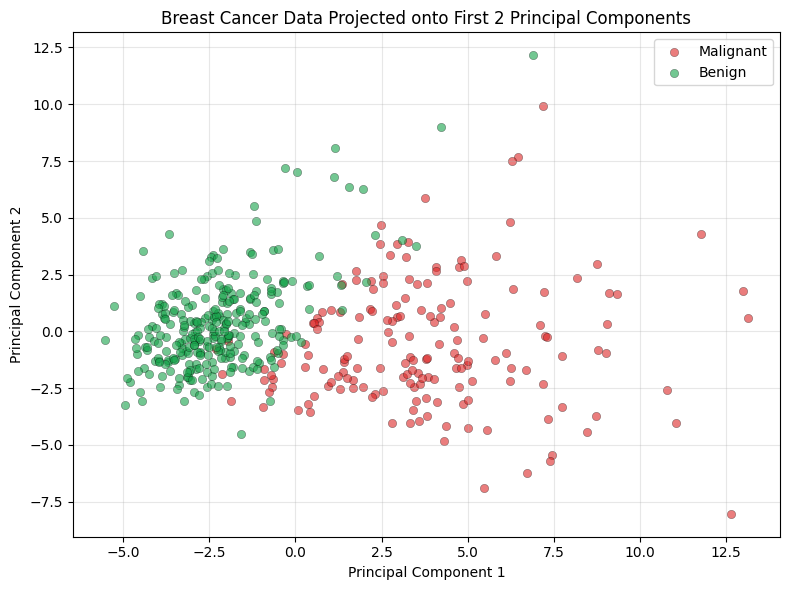

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = {0: "#dc2626", 1: "#16a34a"}
labels = {0: "Malignant", 1: "Benign"}

for class_value in np.unique(y_train):
    mask = y_train == class_value
    ax.scatter(X_train_pca2[mask, 0], X_train_pca2[mask, 1],
               c=colors[class_value], label=labels[class_value],
               alpha=0.6, edgecolors="k", linewidths=0.3)

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_title("Breast Cancer Data Projected onto First 2 Principal Components")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Reading this plot:** if the two classes form mostly separate clusters even in just 2 dimensions that tells us most of the *class-relevant* signal survives extreme compression, which would explain why a model might still perform reasonably well on just 2 components. If the classes overlap heavily, that's a sign real information got discarded.


### Final comparison: accuracy, training time, and feature count

In [23]:
results_df = pd.DataFrame(results)
results_df = results_df[["Condition", "Model", "Features", "Accuracy", "Train Time (s)"]]
results_df["Accuracy"] = results_df["Accuracy"].round(4)
results_df["Train Time (s)"] = results_df["Train Time (s)"].round(5)
results_df


,Condition,Model,Features,Accuracy,Train Time (s)
0,No PCA,Logistic Regression,30,0.9825,0.05675
1,No PCA,KNN,30,0.9561,0.00589
2,No PCA,Random Forest,30,0.9561,0.52656
3,PCA 95%,Logistic Regression,10,0.9737,0.01138
4,PCA 95%,KNN,10,0.9561,0.00986
5,PCA 95%,Random Forest,10,0.9211,0.48757
6,PCA 10,Logistic Regression,10,0.9737,0.02824
7,PCA 10,KNN,10,0.9561,0.01271
8,PCA 10,Random Forest,10,0.9211,0.46933
9,PCA 2,Logistic Regression,2,0.9474,0.00960


In [24]:
pivot_acc = results_df.pivot(index="Model", columns="Condition", values="Accuracy")
pivot_acc = pivot_acc[["No PCA", "PCA 95%", "PCA 10", "PCA 2"]]
pivot_acc


Condition,No PCA,PCA 95%,PCA 10,PCA 2
Model,,,,
KNN,0.9561,0.9561,0.9561,0.9211
Logistic Regression,0.9825,0.9737,0.9737,0.9474
Random Forest,0.9561,0.9211,0.9211,0.9211


In [25]:
pivot_time = results_df.pivot(index="Model", columns="Condition", values="Train Time (s)")
pivot_time = pivot_time[["No PCA", "PCA 95%", "PCA 10", "PCA 2"]]
pivot_time


Condition,No PCA,PCA 95%,PCA 10,PCA 2
Model,,,,
KNN,0.00589,0.00986,0.01271,0.00324
Logistic Regression,0.05675,0.01138,0.02824,0.00960
Random Forest,0.52656,0.48757,0.46933,0.36498
